In [1]:
from PipingSystem import PipingSystem
from Elements.Coil import Coil
from Elements.Singularities import SingularityLoss
from Elements.Tube import Tube
import CoolProp.CoolProp as cp
import numpy as np
from Pumps.Lauda import LaudaPumpFit
import matplotlib.pyplot as plt
from scipy.optimize import newton
import Experiments.NaturalConvection as nc
import ht 

Definimos serpentin

In [2]:
coil = Coil(d_in = 12.6e-3, d_out=13.6e-3, lenght=7.3, orientation=-90, material="copper", vueltas = 14, pitch=13.6e-3)

In [ ]:
#coil = Coil(d_in = 5.15e-3, d_out=6.35e-3, lenght=0.880, orientation=-90, material="copper", vueltas = 5, pitch=12e-3)

In [4]:
np.sqrt((166)**2+((13.6)/(np.pi))**2)*np.pi*14

np.float64(7303.543568691706)

Definimos el sistema

In [3]:
fluxsys = PipingSystem()
fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Primera manguera del lauda
fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Primer cambio de diametro
fluxsys.add_coil(coil) # Serpentin
fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Segundo cambio de diamtro
fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.6e-3, lenght=0.346, orientation=90, material="copper"))
fluxsys.add_singularity_loss(SingularityLoss(0.5)) # Segundo cambio de diamtro
fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Segunda manguera del lauda
fluxsys.conect() # Conectar

In [6]:
coil.roughness

1e-06

Definimos el Fluido

In [4]:
tl = 273.15 + 8.26
pl = 101325        
mul = 0.002 # Pa*s
rhol = 986.58 # kg/m3
cpl = 4180*1.03 # J /(kg K)
kl = 0.4984 # W/(m K)
prl = mul*cpl/kl


print(prl, kl)

17.276886035313005 0.4984


Buscamos donde cruza la curva del sistema con la curva de la bomba

In [5]:
Q_op, Q_op_lmin, dp_op, dh_op = fluxsys.cross_system_pump(rhol,mul, LaudaPumpFit.Pa4m3s, 3.25e-5,verbose=True);


═════════════════════════════════════════════
        UNTO DE OPERACIÓN DEL SISTEMA        
═════════════════════════════════════════════
 Caudal volumétrico :    5.734 L/min
 Caudal volumétrico      : 9.56e-05 m³/s
 Presión de cruce   :  14122.5 Pa
 Pérdida de altura  :    1.459 m.c.a.
═════════════════════════════════════════════



In [ ]:
coil.al

In [ ]:
m_dot = Q_op*rhol
# coil = TuClaseSerpentin(...)
# cpl, kl, mul, prl, rhol = ... (Propiedades del fluido interno)

def calcular_salida_y_pared(twater, tin, twall_guess=283.15):
    """
    Simulador predictivo real: Asume que Tin es fijo y DESCONOCE Tout.
    Encuentra Twall y Tout iterando el circuito de resistencias térmicas.
    """
    tol = 0.1
    relax = 0.1
    max_iter = 100000
    
    twall_out = twall_guess # Iteramos sobre la pared exterior
    tout = tin + 1.0        # Valor inicial lógico (sale un poco más caliente de lo que entra)
    q = 0
    
    for i in range(max_iter):
        
        # --- 1) LADO INTERNO (Fluido) ---
        Re = (4 * m_dot) / (np.pi * coil.d_in * mul)
        
        coil.set_hidraulica(Q_op, rhol, mul)
        hi = coil.get_ht(prl,prl,mul,mul,kl)
        
        R_int = 1 / (hi * coil.area_in)
        
        # MÉTODO NTU: Transforma la resistencia interna para garantizar 
        # que el perfil de temperatura no rompa la termodinámica
        NTU = 1 / (R_int * m_dot * cpl)
        epsilon = 1 - np.exp(-NTU)
        R_eff_int = 1 / (epsilon * m_dot * cpl)
        
        # --- 2) PARED (Conducción) ---
        R_cond = np.log(coil.d_out / coil.d_in) / (2 * np.pi * coil.conductivity * coil.lenght)
        
        # --- 3) LADO EXTERNO (Baño y Rayleigh) ---
        tfo = (twater + twall_out) / 2
        if np.isnan(tfo) or tfo < 273.16: tfo = 273.20
            
        beta = cp.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', tfo, 'P', 101325, "water")
        prandtl = cp.PropsSI('Prandtl', 'T', tfo, 'P', 101325, "water")
        nu_o = cp.PropsSI('V', 'T', tfo, 'P', 101325, "water") / cp.PropsSI('D', 'T', tfo, 'P', 101325, "water")
        k_bath = cp.PropsSI('L', 'T', tfo, 'P', 101325, "water")
        
        delta_T = abs(twater - twall_out)
        if delta_T < 0.01: delta_T = 0.01
            
        # IMPORTANTE: Grashof ahora se calcula con el diámetro exterior (coil.d_out), NO con la altura
        gr = (9.81 * beta * delta_T * (coil.d_out**3)) / (nu_o**2)
        
        # Si tu serpentín está acostado en el estanque, cambia a horizontal=True
        Nuo = ht.conv_free_immersed.Nu_coil_Xin_Ebadian(Pr=prandtl, Gr=gr, horizontal=False)
        
        # Despejamos el coeficiente convectivo (h_o) usando el diámetro exterior para mantener consistencia
        ho = (Nuo * k_bath) / coil.d_out
        
        R_ext = 1 / (ho * coil.area_out)
        
        # --- 4) BALANCE TÉRMICO GLOBAL ---
        R_tot = R_eff_int + R_cond + R_ext
        
        # El calor real está dictado por el diferencial total: Baño vs Entrada fría
        q_new = (twater - tin) / R_tot
        
        # --- 5) RECALCULAR TEMPERATURAS (Física Pura) ---
        twall_out_new = twater - q_new * R_ext
        tout_new = tin + q_new / (m_dot * cpl)
        
        # --- 6) CONVERGENCIA ---
        # Solo necesitamos que la pared converja, el fluido será consecuencia directa del calor
        if abs(twall_out_new - twall_out) < tol:
            twall_out = twall_out_new
            tout = tout_new
            q = q_new
            break
            
        # Relajación
        twall_out = twall_out + relax * (twall_out_new - twall_out)
        
    return tout, twall_out, q




In [12]:

M_tanque = 19.978 # Masa de agua en el baño (kg)
Cp_tanque = 4180  # J/kgC (Calor específico del agua)
dt = 0.5          # Paso de tiempo en segundos
tiempo_total = 20*60 # 20 minutos en segundos

# Condiciones iniciales de la simulación
t_bath_actual = 273.15 + 16 # Temperatura inicial del baño (Ej: 20°C en Kelvin)
tin = 273.15+ 8.2    # Temperatura de entrada al serpentín (Ej: 80°C en Kelvin)

# Listas para guardar el historial y graficar después
historial_tiempo = []
historial_t_bath = []
historial_tout = []
historial_q = []
historial_twall = []

print("Iniciando simulación de 20 minutos...")

for t in np.arange(0, tiempo_total, dt):
    # 'tin' se mantiene constante a 273.15 + 8 (o lo que dictes)
    if t == 0:
        tout, twall_out, q = calcular_salida_y_pared(t_bath_actual, tin)
    else:
        tout, twall_out, q = calcular_salida_y_pared(t_bath_actual, tin, twall_guess=twall_out)
    
    # 2. Guardar datos actuales en el historial
    historial_tiempo.append(t / 60.0) # Guardar en minutos
    historial_t_bath.append(t_bath_actual - 273.15) # Guardar en Celsius para fácil lectura
    historial_tout.append(tout - 273.15)
    historial_q.append(q)
    historial_twall.append(twall_out - 273.15)
    
    
    # 3. Calcular el cambio de temperatura del baño
    dT_bath = (-q * dt) / (M_tanque * cp.PropsSI('C', 'T', t_bath_actual, 'P', 101325, "water"))
    
    # 4. Actualizar temperatura para el siguiente segundo
    t_bath_actual += dT_bath

print("Simulación finalizada.")

# --- VISUALIZACIÓN DE RESULTADOS ---


Iniciando simulación de 20 minutos...
Simulación finalizada.


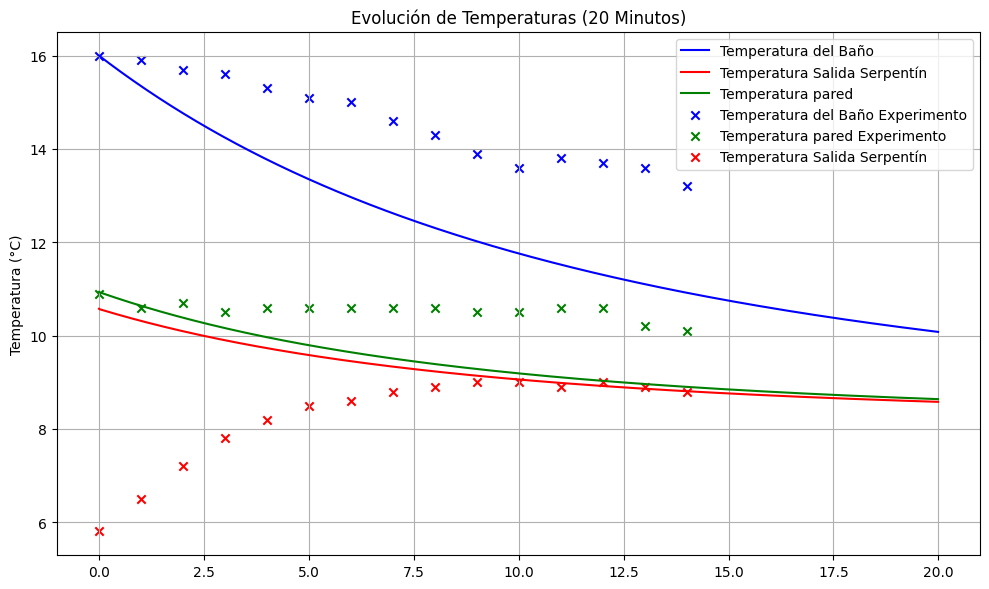

In [13]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 1, 1)
plt.plot(historial_tiempo, historial_t_bath, label="Temperatura del Baño", color='blue')
plt.plot(historial_tiempo, historial_tout, label="Temperatura Salida Serpentín", color='red')
plt.plot(historial_tiempo, historial_twall, label ="Temperatura pared", color = "green")
plt.scatter(nc.tiempo, nc.twater, label="Temperatura del Baño Experimento", color='blue', marker="x")
plt.scatter(nc.tiempo, nc.tpared, label="Temperatura pared Experimento", color='green', marker="x")
plt.scatter(nc.tiempo, nc.t_lauda, label="Temperatura Salida Serpentín", color='red', marker="x")

plt.title("Evolución de Temperaturas (20 Minutos)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)

# plt.subplot(2, 1, 2)
# plt.plot(historial_tiempo, historial_q, label="Calor Transferido (q)", color='orange')
# plt.xlabel("Tiempo (Minutos)")
# plt.ylabel("Calor (W)")
# plt.legend()
# plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# --- SIMULACIÓN TRANSITORIA (20 MINUTOS) ---

M_tanque = 0.350*0.9985 # Masa de agua en el baño (kg)
Cp_tanque = 4180  # J/kgC (Calor específico del agua)
dt = 0.5          # Paso de tiempo en segundos
tiempo_total = 10*60 # 20 minutos en segundos

# Condiciones iniciales de la simulación
t_bath_actual = 273.15+16 # Temperatura inicial del baño (Ej: 20°C en Kelvin)
tin = 273.15+5         # Temperatura de entrada al serpentín (Ej: 80°C en Kelvin)

# Listas para guardar el historial y graficar después
historial_tiempo = []
historial_t_bath = []
historial_tout = []
historial_q = []
historial_twall = []

print("Iniciando simulación de 20 minutos...")

for t in np.arange(0, tiempo_total, dt):
    # 'tin' se mantiene constante a 273.15 + 8 (o lo que dictes)
    if t == 0:
        tout, twall_out, q = calcular_salida_y_pared(t_bath_actual, tin)
    else:
        tout, twall_out, q = calcular_salida_y_pared(t_bath_actual, tin, twall_guess=twall_out)
    
    # 2. Guardar datos actuales en el historial
    historial_tiempo.append(t / 60.0) # Guardar en minutos
    historial_t_bath.append(t_bath_actual - 273.15) # Guardar en Celsius para fácil lectura
    historial_tout.append(tout - 273.15)
    historial_q.append(q)
    historial_twall.append(twall_out - 273.15)
    
    
    # 3. Calcular el cambio de temperatura del baño
    dT_bath = (-q * dt) / (M_tanque * cp.PropsSI('C', 'T', t_bath_actual, 'P', 101325, "water"))
    
    # 4. Actualizar temperatura para el siguiente segundo
    t_bath_actual += dT_bath

print("Simulación finalizada.")

Iniciando simulación de 20 minutos...
Simulación finalizada.


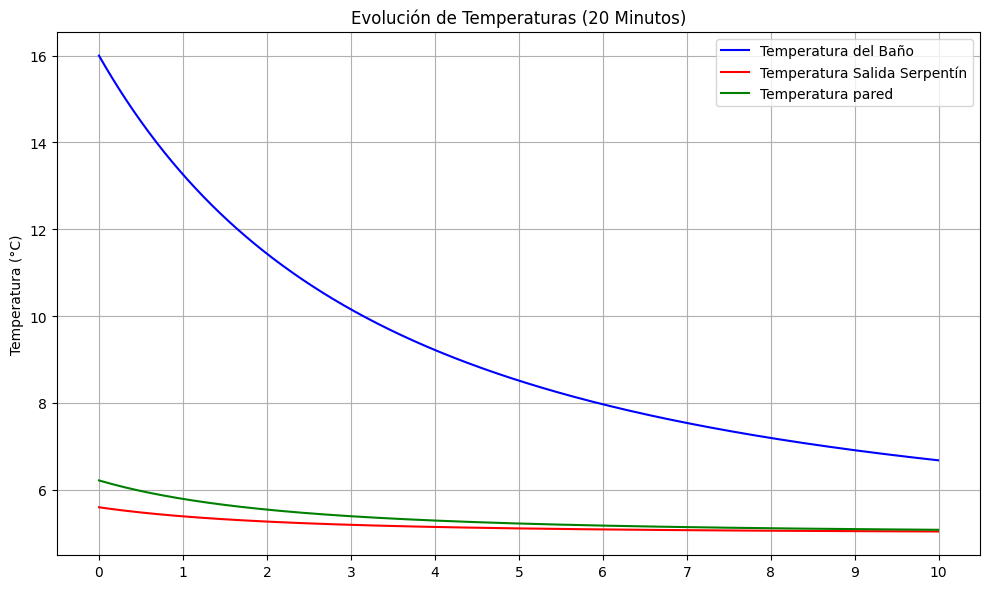

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 1, 1)
plt.plot(historial_tiempo, historial_t_bath, label="Temperatura del Baño", color='blue')
plt.plot(historial_tiempo, historial_tout, label="Temperatura Salida Serpentín", color='red')
plt.plot(historial_tiempo, historial_twall, label ="Temperatura pared", color = "green")
plt.xticks([0,1,2,3,4,5,6,7,8,9,10])
plt.title("Evolución de Temperaturas (20 Minutos)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)

# plt.subplot(2, 1, 2)
# plt.plot(historial_tiempo, historial_q, label="Calor Transferido (q)", color='orange')
# plt.xlabel("Tiempo (Minutos)")
# plt.ylabel("Calor (W)")
# plt.legend()
# plt.grid(True)

plt.tight_layout()
plt.show()